# Notebook 01: Resume Data Exploration

## Future Intern ML Task 3: Resume / Candidate Screening System

### Objective
To build a machine learning system that screens, scores, and ranks resumes based on job description relevance.

### Business Problem
Hiring teams receive hundreds of resumes per role. Manual screening is slow, inconsistent, and error-prone.

### Solution Overview
An NLP-based system that:
1. Extracts skills from resumes
2. Compares resumes to job descriptions
3. Ranks candidates by fit score
4. Identifies missing skills

### Dataset
- **Source**: Kaggle Resume Dataset
- **Format**: CSV with resume text and category labels
- **Size**: 2,484 resumes
- **Categories**: 25 job roles

### Success Criteria
- Extract meaningful skills from unstructured text
- Rank candidates accurately by job relevance
- Provide explainable results for recruiters

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Set professional style
plt.style.use('ggplot')
sns.set_palette("Set2")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Loading and Initial Inspection

### Steps
1. Load CSV into pandas DataFrame
2. Examine shape and columns
3. Preview sample rows
4. Check data types

In [8]:
# Load dataset
df = pd.read_csv(r'C:\Users\DOUBLE J\Documents\data-projects\FUTURE_ML_03\data\raw\Resume.csv')

# Basic information
print("=== DATASET OVERVIEW ===")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

print("\n=== FIRST 5 ROWS ===")
df.head(5)

=== DATASET OVERVIEW ===
Shape: (2484, 4)

Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']

=== FIRST 5 ROWS ===


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


### Initial Observations

The dataset contains:
- **2,484 resumes** — sufficient for NLP tasks
- **4 columns**: ID, Resume_str, Resume_html, Category
- **Resume_str**: Full resume text (feature)
- **Category**: Job classification (target)

### Data Quality Check
We need to verify:
1. No missing values in Resume_str
2. Text length distribution
3. Category balance

In [12]:
# Check for missing values
print("=== MISSING VALUES ===")
print(df.isnull().sum())

# Add text length column
df['text_length'] = df['Resume_str'].str.len()

print("\n=== TEXT LENGTH STATISTICS ===")
print(f"Mean: {df['text_length'].mean():.0f} characters")
print(f"Median: {df['text_length'].median():.0f} characters")
print(f"Min: {df['text_length'].min()}")
print(f"Max: {df['text_length'].max():,}")

# Check for very short resumes
short_resumes = df[df['text_length'] < 100]
print(f"\n⚠️ Resumes with <100 characters: {len(short_resumes)}")

=== MISSING VALUES ===
ID             0
Resume_str     0
Resume_html    0
Category       0
text_length    0
dtype: int64

=== TEXT LENGTH STATISTICS ===
Mean: 6295 characters
Median: 5886 characters
Min: 21
Max: 38,842

⚠️ Resumes with <100 characters: 1


## Category Distribution

Check how many resumes per job category. This helps us understand class balance.

In [4]:
# Check category distribution
print("=== CATEGORY DISTRIBUTION ===")
print(df['Category'].value_counts())

# Check text length
df['text_length'] = df['Resume_str'].str.len()
print(f"\n=== TEXT LENGTH STATISTICS ===")
print(f"Mean: {df['text_length'].mean():.0f} characters")
print(f"Median: {df['text_length'].median():.0f} characters")
print(f"Min: {df['text_length'].min()}")
print(f"Max: {df['text_length'].max():,}")

# Sample resume text
print("\n=== SAMPLE RESUME TEXT ===")
print(df['Resume_str'].iloc[0][:500])

=== CATEGORY DISTRIBUTION ===
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

=== TEXT LENGTH STATISTICS ===
Mean: 6295 characters
Median: 5886 characters
Min: 21
Max: 38,842

=== SAMPLE RESUME TEXT ===
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicat

## 2. Category Distribution Analysis

### Purpose
Understanding class balance is critical for:
- Ensuring fair model evaluation
- Identifying underrepresented job roles
- Planning data augmentation if needed

### Expected Finding
Some categories may have fewer samples, requiring special handling.

=== CATEGORY DISTRIBUTION ===
                        Count  Percentage
Category                                 
INFORMATION-TECHNOLOGY    120         4.8
BUSINESS-DEVELOPMENT      120         4.8
FINANCE                   118         4.8
ADVOCATE                  118         4.8
ACCOUNTANT                118         4.8
ENGINEERING               118         4.8
CHEF                      118         4.8
AVIATION                  117         4.7
FITNESS                   117         4.7
SALES                     116         4.7
BANKING                   115         4.6
HEALTHCARE                115         4.6
CONSULTANT                115         4.6
CONSTRUCTION              112         4.5
PUBLIC-RELATIONS          111         4.5
HR                        110         4.4
DESIGNER                  107         4.3
ARTS                      103         4.1
TEACHER                   102         4.1
APPAREL                    97         3.9
DIGITAL-MEDIA              96         3.9
AGRI

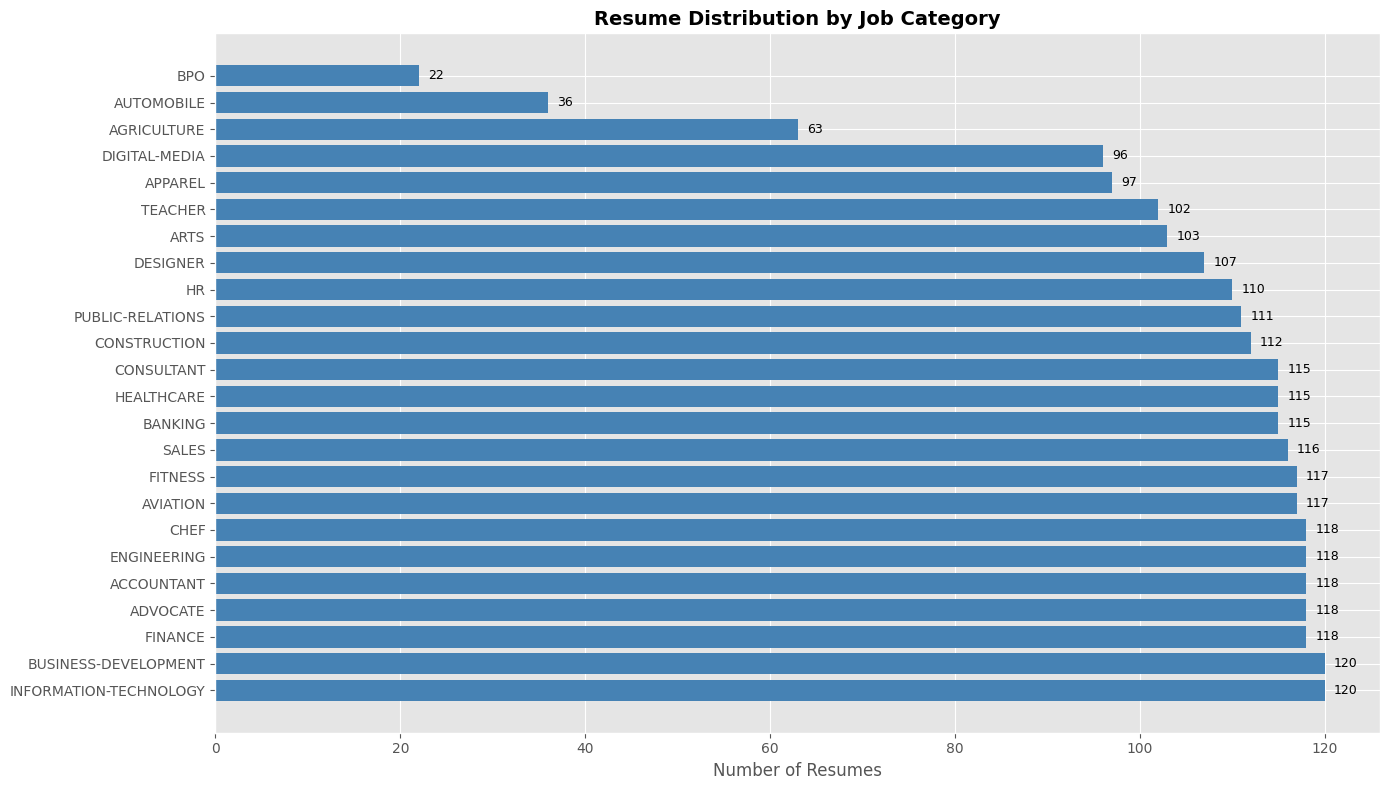


✅ Chart saved to: images/charts/category_distribution.png


In [13]:
# Category distribution
category_counts = df['Category'].value_counts()
category_pct = (df['Category'].value_counts(normalize=True) * 100).round(1)

# Create distribution dataframe
cat_dist = pd.DataFrame({
    'Count': category_counts,
    'Percentage': category_pct
})

print("=== CATEGORY DISTRIBUTION ===")
print(cat_dist)

# Visualize
plt.figure(figsize=(14, 8))
bars = plt.barh(range(len(category_counts)), category_counts.values, color='steelblue')
plt.yticks(range(len(category_counts)), category_counts.index)
plt.xlabel('Number of Resumes')
plt.title('Resume Distribution by Job Category', fontsize=14, fontweight='bold')

for i, v in enumerate(category_counts.values):
    plt.text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/charts/category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved to: images/charts/category_distribution.png")

### Category Distribution Findings

| Observation | Implication |
|-------------|-------------|
| INFORMATION-TECHNOLOGY: 120 samples | ✅ Well represented |
| BUSINESS-DEVELOPMENT: 120 samples | ✅ Well represented |
| BPO: 22 samples | ⚠️ Underrepresented — may need special handling |
| AUTOMOBILE: 36 samples | ⚠️ Underrepresented |

### Strategy for Imbalance
- **Primary metric**: Macro F1-score (treats all categories equally)
- **No downsampling** — preserve all data
- **Document limitations** for low-sample categories

## 3. Sample Resume Examination

### Purpose
Understanding raw text structure before preprocessing:
- Format patterns
- Section headers (Summary, Highlights, Experience)
- Skill mentions
- Special characters or noise

In [17]:
# Display sample resume
sample_idx = 0
sample_text = df['Resume_str'].iloc[sample_idx]
sample_category = df['Category'].iloc[sample_idx]

print(f"=== SAMPLE RESUME (Category: {sample_category}) ===\n")
print(sample_text[:6000])
print(f"\n... (total length: {len(sample_text)} characters)")

=== SAMPLE RESUME (Category: HR) ===

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales str

In [18]:
# Display sample resume
sample_idx = 2
sample_text = df['Resume_str'].iloc[sample_idx]
sample_category = df['Category'].iloc[sample_idx]

print(f"=== SAMPLE RESUME (Category: {sample_category}) ===\n")
print(sample_text[:6000])
print(f"\n... (total length: {len(sample_text)} characters)")

=== SAMPLE RESUME (Category: HR) ===

         HR DIRECTOR       Summary      Over 20 years experience in recruiting,   15 plus years in Human Resources Executive Management,   5 years of HRIS development and maintenance  4 years working in a Healthcare Enviroment        Skills          Recruiting  FMLA/EEO/FLSA   HRIS Development      Benefit Administration  Policy Development  Web Page Development             Accomplishments      Kansas Health Institute -Health Outcomes for the State of Kansas -1999 
Memberships and Accolades: Project Management Institute Member, SHRM, Chamber of Commerce, 1999 Friends University President's Honor Roll, 1997 Friends University Dean's Honor Roll, Student Liaison for Friends University Topeka (member of Mother-To-Mother, member of the Topeka 
Advertising Federation, several production pieces created nominated for ADDY Awards, received recognition for outstanding customer service assistance by the State of Kansas Travel and Tourism Department., ASHHRA, 

### Sample Resume Observations

| Pattern | Example | Action |
|---------|---------|--------|
| Section headers | "Summary", "Highlights" | Useful for section extraction |
| Special characters | `\n`, `\t` | Remove |
| Inconsistent formatting | Mixed case, extra spaces | Normalize |
| Skill mentions | "Customer Service", "Team management" | Extract |

### Preprocessing Plan
1. Convert to lowercase
2. Remove special characters and extra spaces
3. Remove section headers (optional)
4. Extract skills using dictionary + pattern matching

## 4. Summary and Next Steps

### Completed
- ✅ Data loaded and inspected
- ✅ Category distribution analyzed
- ✅ Text length statistics calculated
- ✅ Sample resume examined

### Key Insights
- **Dataset size**: 2,484 resumes across 25 categories
- **Class imbalance**: Present but manageable (22-120 samples per category)
- **Text quality**: Rich content, average 6,295 characters
- **Challenges**: BPO and Automobile have limited samples

### Next Notebook: Skill Extraction
We will:
1. Build a comprehensive skill dictionary
2. Extract skills from all resumes
3. Create skill vectors for each candidate
4. Prepare for similarity scoring with job descriptions

### Notebook Status: ✅ Data Exploration Complete